## Part B - Partical (Python Programming)

## Import Libraries

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from numpy.linalg import norm


## Import Dataset

In [2]:
df = pd.read_csv("student_performance_5000.csv")
print(df.head())

   student_id  Age  Math_score  Science_score  English_score  Hours_studied  \
0           1   17          54             65             59            0.2   
1           2   24          39             57             63            0.7   
2           3   19          50             56             62            1.9   
3           4   22          43             47             55            1.8   
4           5   16          86             91             77            6.1   

   pass_fail  
0          1  
1          1  
2          1  
3          0  
4          1  


## Step 1: Measures of Central Tendency & Dispersion

In [5]:
# Mean, Median, Mode of math score
print()
print("========= Mean, Median, Mode of math score =============")
mean_score = df['Math_score'].mean()
median_score = df['Math_score'].median()
mode_score = df['Math_score'].mode()

print(f"Mean of Math Score:{mean_score}")
print(f"Median of Math Score:{median_score}")
print(f"Mode of Math Score:{mode_score}")

# Range, Variance, Standard Deviation of Science score

print()
print("========= Range, Variance, Standard Deviation of Science score =============")
range_score = df['Science_score'].max() - df['Science_score'].min()
variance_score = df['Science_score'].var()
standard_deviation_score = df['Science_score'].std()

print(f"Range of Science Score:{range_score}")
print(f"Variance of Science Score:{variance_score}")
print(f"Standard Deviation of Science Score:{standard_deviation_score}")


========= Mean, Median, Mode of math score =============
Mean of Math Score:70.4252
Median of Math Score:71.0
Mode of Math Score:0    100
Name: Math_score, dtype: int64

========= Range, Variance, Standard Deviation of Science score =============
Range of Science Score:71
Variance of Science Score:195.4652120424085
Standard Deviation of Science Score:13.980887383939852


## Step 2: Probability Basics

In [8]:
print()
print("========== Probability of Passing ==============")
prob_pass = (df["pass_fail"] == 1).mean()
print(f"Probability of Passing: {prob_pass}")

print()
print("========== Contingency Table ==============")
df["Hours_Studied_GT5"] = df["Hours_studied"] > 5 
cont_table = pd.crosstab(df["pass_fail"],
                         df["Hours_Studied_GT5"])
print(cont_table)

print()
print("========== Conditional Probability ==============")
Student = df[df["Hours_studied"]> 5]
passed = Student[Student["pass_fail"] == 1]
conditional_prob = len(passed)/len(Student)
print(f"P(pass | Hours_studied > 5)= {conditional_prob}")


========== Probability of Passing ==============
Probability of Passing: 0.9862

========== Contingency Table ==============
Hours_Studied_GT5  False  True 
pass_fail                      
0                     69      0
1                   3116   1815

========== Conditional Probability ==============
P(pass | Hours_studied > 5)= 1.0


## Step 3: Distribution & Visualization 



=============================== Histogram =======================================================


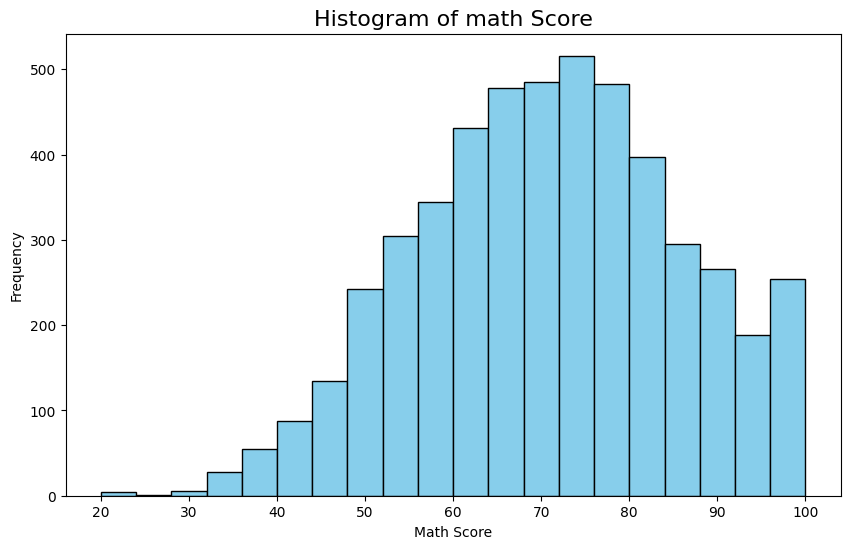


======================================= Normal Curve =============================================


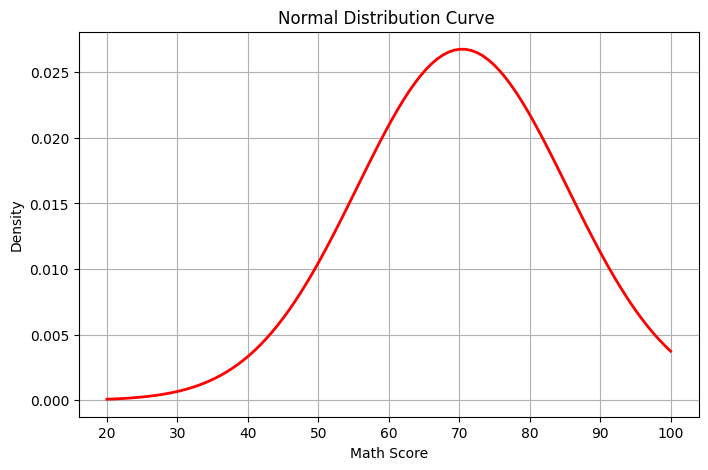

In [10]:
print()
print("=============================== Histogram =======================================================")
plt.figure(figsize=(10,6))
plt.hist(df['Math_score'], bins=20, color='Skyblue', edgecolor='black')
plt.title('Histogram of math Score', fontsize=16)
plt.xlabel('Math Score')
plt.ylabel('Frequency')
plt.show()

print()
print("======================================= Normal Curve =============================================")
mu = df['Math_score'].mean()
sigma = df['Math_score'].std()
x = np.linspace(df['Math_score'].min(), df['Math_score'].max(), 100)
y = stats.norm.pdf(x, mu, sigma)
plt.figure(figsize=(8,5))
plt.plot(x,y,color='red',linewidth = 2)
plt.title('Normal Distribution Curve ')
plt.xlabel("Math Score")
plt.ylabel("Density")
plt.grid(True)
plt.show()


In [11]:
print("================================= Skewness & Kurtosis ======================================")
skewness = df['Science_score'].skew()
kurtosis = df['Science_score'].kurtosis()

print("Skewness of Science Score:", skewness)
print("Kurtosis of Science Score:", kurtosis)

================================= Skewness & Kurtosis ======================================
Skewness of Science Score: -0.09936535568422715
Kurtosis of Science Score: -0.4958081517702291


================================ Q-Q Plot =============================================


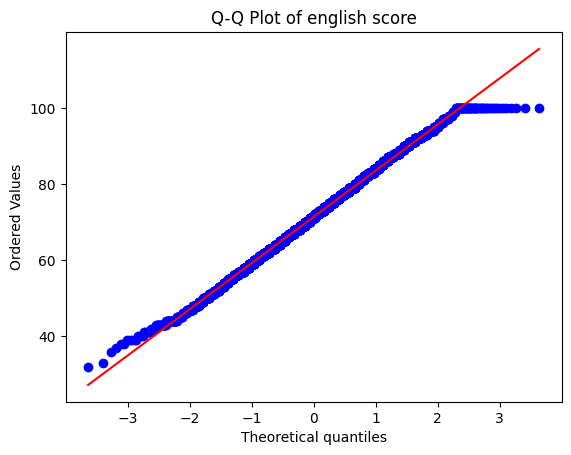

In [12]:
print("================================ Q-Q Plot =============================================")
stats.probplot(df['English_score'], dist="norm",plot=plt)
plt.title("Q-Q Plot of english score")
plt.show()

## Step 4: Linear Algebra Mini Task

In [15]:
print("================================ First 5 Students =============================================")

math_vec = df['Math_score'].head().values
science_vec = df['Science_score'].head().values

print()

print("============= Math Vector =============")
print(math_vec)

print()
print("============= Science Vector ============")
print(science_vec)

================================ First 5 Students =============================================

============= Math Vector =============
[54 39 50 43 86]

============= Science Vector ============
[65 57 56 47 91]


In [16]:
print("============ Dot Product ============")

dot_product = np.dot(math_vec,
                     science_vec)
print("Dot Product =", dot_product)

============ Dot Product ============
Dot Product = 18380


In [17]:
print("============== Norm 1 & Norm 2 ============")

norm1 = np.linalg.norm(math_vec, ord=1)
norm2 = np.linalg.norm(math_vec)

print("Norm 1 =",norm1)
print("Norm 2 =", norm2)


============== Norm 1 & Norm 2 ============
Norm 1 = 272.0
Norm 2 = 127.20849028268515


In [18]:
print("=============== Angle Between Two Vectors ================")
cos_theta = np.dot(math_vec, science_vec) / (
    np.linalg.norm(math_vec) *
    np.linalg.norm(science_vec)
)

angle = np.degrees(np.arccos(cos_theta))

print("Angle Between Vectors =", angle)

=============== Angle Between Two Vectors ================
Angle Between Vectors = 5.906592630427921
